# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [29]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [31]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [32]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [33]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [34]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [35]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [36]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [37]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [38]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [39]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- En cuanto a 'user_id' hay dos columnas con valores nulos, 'city' con un 11.72% y churn_date con un 88.35%
- En usage 'date' tiene 0.12% de nulos; 'duration' 55.19% de nulos y 'length' 44.74%
- Indica qué harías: ¿imputar, eliminar, ignorar?
- Planes de acción por columna:
- 'city' creación de columna flag
- 'churn_date' se ignorará
- 'date' eliminaremos los registros
- 'duration' y 'length' se mantienen los valores como NAN para reemplazarse por valor=0 ya que con base en la visualización que se tiene del ds, no son valores nulos sino que son valores que no aplican; 'duration' se encuentra ligado a 'type' == 'call' y 'lenght' se encuentra ligado a 'type' == 'text'. Eliminarlos comprometería sesgar el análisis ya que habría pérdida de datos casi en su totalidad.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [40]:
# explorar columnas numéricas de users
users_numeric_columns=users[["user_id","age",]]
users_numeric_columns.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` no presenta anomalías, la desviación estándar presenta un número elevado, pero se deberá validar la dispersión de los datos mediante histrograma y boxplot
- La columna `age` requiere tratamiento de 'sentinels' ya que el valor mínimo = -999, un valor imposible

In [41]:
# explorar columnas numéricas de usage
usage_numeric_columns=usage[["id","user_id","duration","length"]]
usage_numeric_columns.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` no presentan anomalías
- Las columnas `duration`y `length` a grandes rasgos no presentan información extraordinaria. Cómo comprobación adicional se recomienda visualización gráfica para evaluar posibles outliers, pero que pudieran ser mínimos

In [42]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']]
columnas_user.describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


In [43]:
columnas_user.value_counts()

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city` continúa presentando los valores nulos, analiza la información de  diferentes ciudades en dos países y la ciudad con mayor volumen de datos es Bogotá. Contiene sentinels `?``
- La columna `plan` nos indica que los datos están completos, solo existen dos tipos de plan y que predomina el Básico.

In [44]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` contiene dos tipos de valores, que previamente visualizamos como "call" y "text". No se presentan valores nulos. Predomina "text" pero con una diferencia mínima.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? 
- En la columna `age` 
- ¿Qué acción tomarías?
- Validaría la cantidad de sentinels y reemplazaría el valor por la media o la moda dependiendo la distribución de los datos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [45]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"],errors="coerce")

In [46]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"],errors="coerce")

In [47]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date` se presentan valores correspondientes al año 2026.

In [48]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.unique()

array([2024.,   nan])

En `date`, solo encontramos información del año 2024, y tenemos valores NAN, que deben corresponder al 0.12% que mencionamos previamente.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- El año más viejo es el 2022. El corte del reporte es al 2024, tenemos información de años posteriores (2026)
- ¿Qué harías con ellas?
- Se validará que no sea un error de captura, y de ser así se eliminará su registro

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [49]:
# Reemplazar -999 por la mediana de age

age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999,age_mediana)


# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [50]:
# Reemplazar ? por NA en city
users["city"]=users["city"].replace("?",pd.NA)


# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [51]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year > 2024,"reg_date"] = pd.NaT

# Verificar cambios
users["reg_date"].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [52]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage[usage["type"]=="text"])

          id  user_id  type                          date  duration  length
1          2    11458  text 2024-01-01 00:06:30.969774244       NaN    39.0
2          3    11777  text 2024-01-01 00:13:01.939548488       NaN    36.0
8          9    11530  text 2024-01-01 00:52:07.758193954       NaN    44.0
9         10    12850  text 2024-01-01 00:58:38.727968199       NaN    70.0
11        12    10824  text 2024-01-01 01:11:40.667516687       NaN    31.0
...      ...      ...   ...                           ...       ...     ...
39979  39980    13582  text 2024-06-29 21:49:40.604515112       NaN    41.0
39981  39982    11256  text 2024-06-29 22:02:42.544063600       NaN    48.0
39985  39986    11966  text 2024-06-29 22:28:46.423160578       NaN    58.0
39987  39988    11232  text 2024-06-29 22:41:48.362709066       NaN    52.0
39998  39999    10863  text 2024-06-29 23:53:29.030225754       NaN    43.0

[22092 rows x 6 columns]


In [53]:
# Verificación MAR en usage (Missing At Random) para length
print(usage[usage["type"]=="call"])

          id  user_id  type                          date  duration  length
0          1    10332  call 2024-01-01 00:00:00.000000000      0.09     NaN
3          4    10682  call 2024-01-01 00:19:32.909322733      1.53     NaN
4          5    12742  call 2024-01-01 00:26:03.879096977      4.84     NaN
5          6    10473  call 2024-01-01 00:32:34.848871221      4.68     NaN
6          7    12856  call 2024-01-01 00:39:05.818645466      3.27     NaN
...      ...      ...   ...                           ...       ...     ...
39994  39995    12418  call 2024-06-29 23:27:25.151128778      1.61     NaN
39995  39996    13497  call 2024-06-29 23:33:56.120903022      5.75     NaN
39996  39997    10941  call 2024-06-29 23:40:27.090677266      3.06     NaN
39997  39998    13038  call 2024-06-29 23:46:58.060451510      8.74     NaN
39999  40000    10759  call 2024-06-30 00:00:00.000000000      1.32     NaN

[17908 rows x 6 columns]


Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`

Los nulos encontrados tanto en `duration` como en `length`se clasifican como MAR, ya que dependen de la columna `type`.

`type` contiene dos datos, `text` y `call`

Cuando `type`=="call" `length` es NaN

Cuando `type`=="text" `duration` es NaN

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [62]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text","is_call","duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [63]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={"is_text":"cant_mensajes","is_call":"cant_llamadas","duration":"cant_min_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_min_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [64]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='inner')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_min_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [65]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = user_profile[["age","cant_mensajes","cant_llamadas","cant_min_llamada"]]
columnas_numericas.describe()

,age,cant_mensajes,cant_llamadas,cant_min_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.124531,5.524381,4.478120,23.317054
std,17.692032,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [67]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

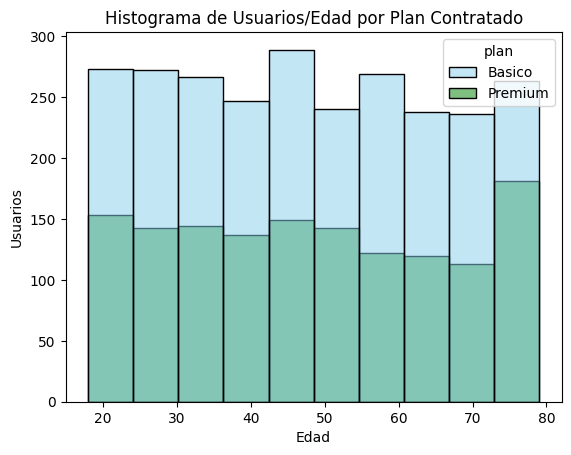

In [77]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,x="age",hue="plan",bins=10,palette=["skyblue","green"])
plt.xlabel("Edad")
plt.ylabel("Usuarios")
plt.title("Histograma de Usuarios/Edad por Plan Contratado")
plt.show()

💡Insights: Ambos planes se comportan de manera similar, contienen un número de promedio de usuarios de acuerdo a su edad. El el plan premium se observa que hay mayor cantidad de usuarios en edades mayores a 75 años, caso contrario con el plan básico que en edades mayores a 75 años se observa menor cantidad de usuarios
- Distribución uniforme

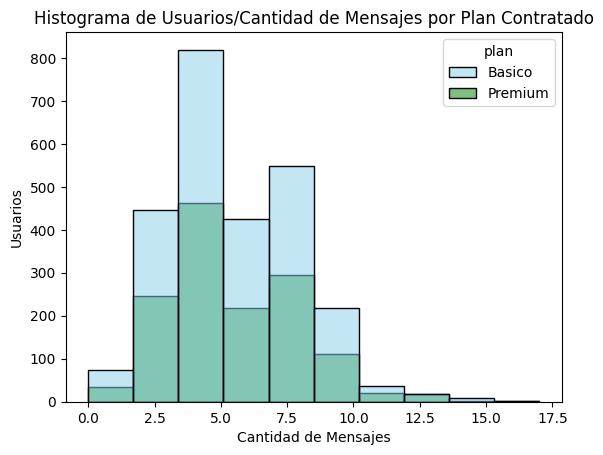

In [78]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile,x="cant_mensajes",hue="plan",bins=10,palette=["skyblue","green"])
plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Usuarios")
plt.title("Histograma de Usuarios/Cantidad de Mensajes por Plan Contratado")
plt.show()

💡Insights: Ambos planes se comportan de manera similar, presentan una menor cantidad de usuarios que envían un mayor número de mensajes.
- Distribución sesgada a la derecha

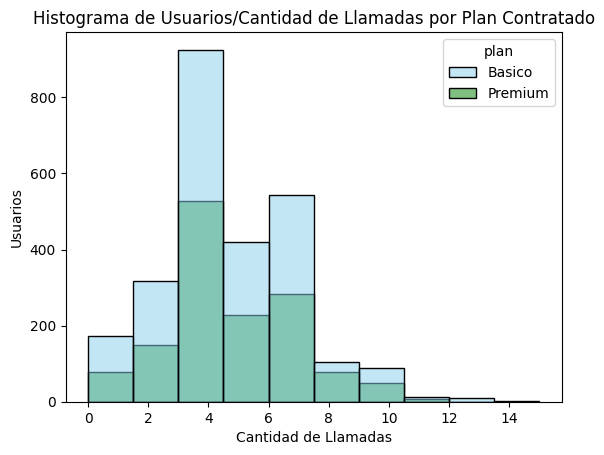

In [79]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile,x="cant_llamadas",hue="plan",bins=10,palette=["skyblue","green"])
plt.xlabel("Cantidad de Llamadas")
plt.ylabel("Usuarios")
plt.title("Histograma de Usuarios/Cantidad de Llamadas por Plan Contratado")
plt.show()

💡Insights: Ambos planes se comportan de manera similar, presentan una menor cantidad de usuarios que realizan un mayor número de llamadas.
- Distribución sesgada a la derecha

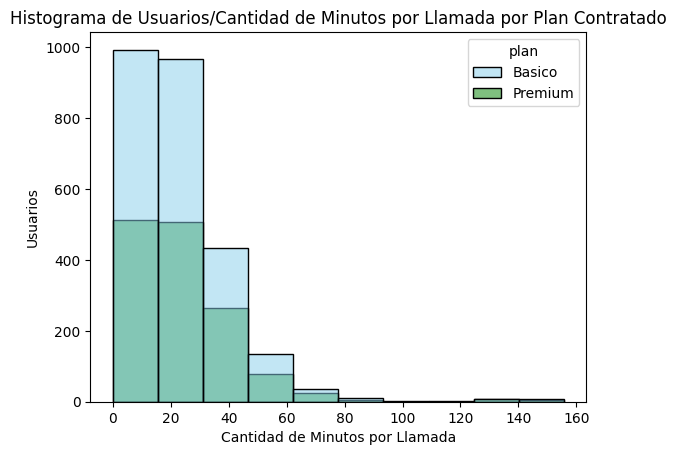

In [80]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile,x="cant_min_llamada",hue="plan",bins=10,palette=["skyblue","green"])
plt.xlabel("Cantidad de Minutos por Llamada")
plt.ylabel("Usuarios")
plt.title("Histograma de Usuarios/Cantidad de Minutos por Llamada por Plan Contratado")
plt.show()

💡Insights: En ambos planes se observa que la mayor cantidad de usuarios realizan llamadas que duran en promedio hasta 35 min. Ligeramente disminuye la cantidad de usuarios que realizan llamadas con mayor cantidad de minutos. Se observa que pocos usuarios con plan premium llegan a tener llamadas que rebasan los 120 min.
- Distribución sesgada a la derecha

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

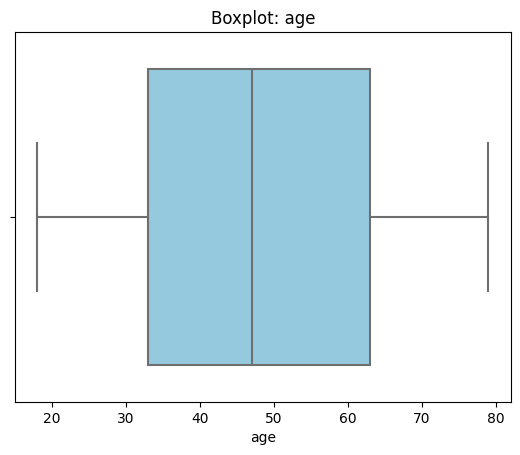

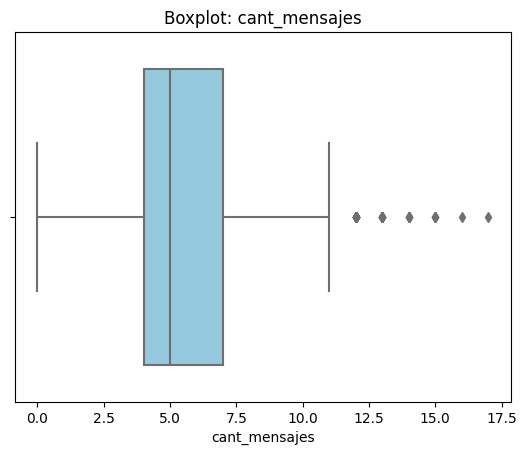

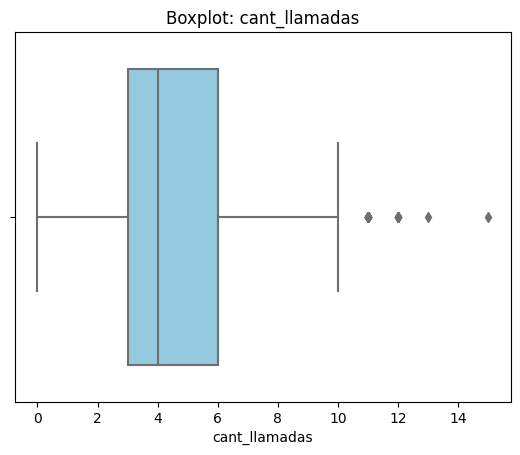

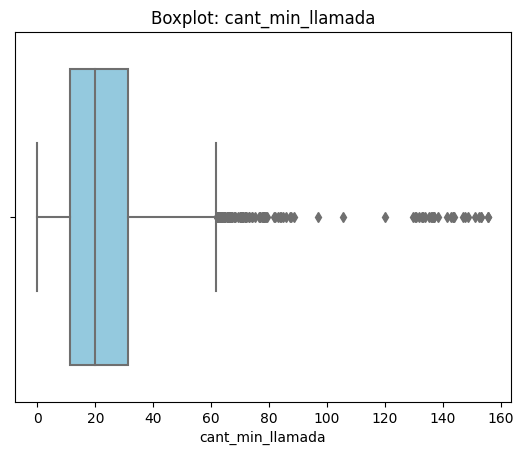

In [85]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_min_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color="skyblue")
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: Presenta una cantidad baja de outliers
- cant_llamadas: Presenta una cantidad baja de outliers
- cant_minutos_llamada: Es la columna con mayor número de outliers creando un sesgo a la derecha

In [97]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_min_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    #print(col,"Q1 = ",Q1)
    #print(col,"Q3 = ",Q3)
    #print(col,"IQR = ",IQR)
    print("Límite superior de ",col," = ",upper)
    


Límite superior de  cant_mensajes  =  11.5
Límite superior de  cant_llamadas  =  10.5
Límite superior de  cant_min_llamada  =  61.8575


In [94]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_min_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- Se mantienen los outliers, porque el valor máximo no rebasa por mucho el límite superior y la desviación estándar es baja
- cant_llamadas: mantener o no outliers, porqué?
- Se mantienen los outliers, porque el valor máximo no rebasa por mucho el límite superior y la desviación estándar es baja
- cant_minutos_llamada: mantener o no outliers, porqué?
- No se mantienen los outliers, porque el valor máximo supera por más del doble el límite superior, así como la desviación estándar señala una mayor disperción de los datos

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [98]:
# Crear columna grupo_uso
def clasificacion_segmento(row):
    mensajes = row["cant_mensajes"]
    llamadas = row["cant_llamadas"]

    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"
    elif llamadas < 10 and mensajes < 10:
        return "Uso medio"
    else:
        return "Alto uso"

user_profile["grupo_uso"] = user_profile.apply(clasificacion_segmento, axis=1)

In [99]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_min_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [100]:
# Crear columna grupo_edad
def clasificacion_edad(row):
    edad = row["age"]

    if edad < 30 :
        return "Joven"
    elif edad < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"

user_profile["grupo_edad"] = user_profile.apply(clasificacion_edad, axis=1)

In [104]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_min_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

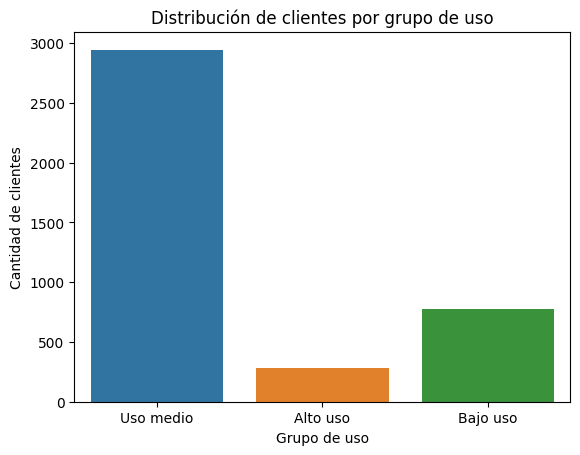

In [105]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso")

plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de clientes')

plt.show()

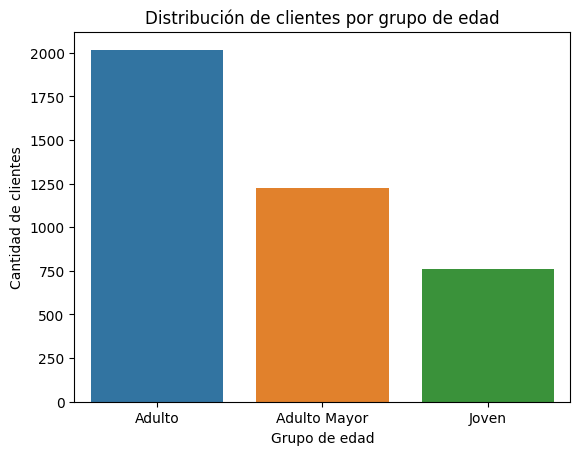

In [106]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad")

plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de clientes')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmente los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
La columna `date`y `reg_date` no se encontraba en formato de fecha.

Se presentaron valores nulos en las siguientes columnas:
`city`11.72%
`churn_date` 88.35%
`length`y `duration`presentaron valores nulos pero no perjudicaron el análisis ya que estaban en relación a la columna `type`de la siguiente manera:
    `type`== "call" length no aplica
    `type`== "text" duration no aplica

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
- Se identificaron 6 tipos de segmentos basados en edad y el uso que se da, se clasificaron en:
      Joven < 30 años
      Adulto < 60 años
      Adulto Mayor > 60 años
      Bajo uso cuando llamadas < 5 y mensajes < 5
      Uso medio cuando llamadas < 10 y mensajes < 10
      Alto uso para el resto de casos

  La mayoría de los clientes se encuentran de la clasificación `Uso Medio` y `Adultos`

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

    Los categorizados como Adultos y Adultos Mayores ya que encabezan el mayor número de clientes activos. 
  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

    Se encontraron outliers en "cant_mensajes", "cant_llamadas" y significativamente más alto "cant_min_llamada" denotando que un sector pequeño de usuarios premium realizan llamadas con duraciones mayores a los 60 min


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Tipos de datos en columnas que indican fecha
- Valores ausentes en la columna `city`


🔍 **Segmentos por Edad**
- Adulto
- Adulto Mayor


📊 **Segmentos por Nivel de Uso**
- Uso medio
- Bajo uso


➡️ Esto sugiere que los clientes en general no generan un uso alto de llamadas o mensajes. El sector joven que es menor a 30 años no es un cliente potencial ya que son pocos los usuarios que se encuentran dentro de esta categoría.


💡 **Recomendaciones**
- Realizar campañas de mercado a clientes mayores a 30 años 
- 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`